# Phase 3 — Hybrid Prophet + XGBoost Revenue Forecasting
**Target:** `Daily_Revenue` | **Horizon:** 548 ngày | **Method:** Prophet (trend) + XGBoost (residual)

In [13]:
# Cell cài đặt toàn bộ thư viện cho Workflow 1, 2 và 3
# %pip sẽ tự động xác định và cài đặt vào môi trường của Kernel đang chạy
# %pip install --upgrade plotly
# %pip install shap notebook
# %pip install pandas numpy matplotlib seaborn scikit-learn prophet xgboost lightgbm shap optuna

In [14]:
# ── 0. SETUP ──────────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import shap
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "font.family": "sans-serif"
})

DATA   = "csv/ml_ready/"
RANDOM = 42

def competition_metrics(y_true, y_pred, label=""):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    wape = np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()
    print(f"  {label:<16} | MAE: {mae:>10,.0f} | RMSE: {rmse:>10,.0f} | R\u00b2: {r2:>7.4f} | WAPE: {wape:.4f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "WAPE": wape}

print("Phase 3 Initialization Complete. Libraries loaded.")


Phase 3 Initialization Complete. Libraries loaded.


In [15]:
# ══════════════════════════════════════════════════════════════════
# 1. LOAD DATA & CYCLICAL TIME ENCODING
# ══════════════════════════════════════════════════════════════════
train = pd.read_csv(DATA + "ts_train.csv")
val   = pd.read_csv(DATA + "ts_val.csv")

for df in (train, val):
    df["order_date"] = pd.to_datetime(df["order_date"])
    df.sort_values("order_date", inplace=True)
    df.reset_index(drop=True, inplace=True)

def engineer_time_features(df):
    """Injects Cyclical Time Features to prevent boundary errors in XGBoost."""
    d = df["order_date"].dt
    
    # Base Calendar
    df["Year"] = d.year
    df["Month"] = d.month
    df["Quarter"] = d.quarter
    df["Week_of_Year"] = d.isocalendar().week.astype(int)
    df["Day_of_Month"] = d.day
    df["Day_of_Week"] = d.dayofweek
    df["Day_of_Year"] = d.dayofyear
    
    # Boolean Flags
    df["Is_Weekend"] = (df["Day_of_Week"] >= 5).astype(int)
    df["Is_Month_Start"] = d.is_month_start.astype(int)
    df["Is_Month_End"] = d.is_month_end.astype(int)
    df["Is_Quarter_End"] = d.is_quarter_end.astype(int)
    df["Is_Year_End"] = ((d.month == 12) & (d.day == 31)).astype(int)
    
    #Cyclical Encoding (Sine/Cosine Transforms)
    df['sin_dow'] = np.sin(2 * np.pi * df['Day_of_Week'] / 7)
    df['cos_dow'] = np.cos(2 * np.pi * df['Day_of_Week'] / 7)
    df['sin_doy'] = np.sin(2 * np.pi * df['Day_of_Year'] / 365.25)
    df['cos_doy'] = np.cos(2 * np.pi * df['Day_of_Year'] / 365.25)
    df['sin_month'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['Month'] / 12)
    
    return df

train, val = engineer_time_features(train), engineer_time_features(val)

# Leakage Verification
assert val.order_date.min()  > train.order_date.max(), "LEAKAGE: Val overlaps Train!"

print(f"Train: {train.order_date.min().date()} → {train.order_date.max().date()} ({len(train)} days)")
print(f"Val  : {val.order_date.min().date()} → {val.order_date.max().date()} ({len(val)} days)")

Train: 2013-07-04 → 2021-12-31 (3103 days)
Val  : 2022-01-01 → 2022-06-30 (181 days)


In [16]:
# ══════════════════════════════════════════════════════════════════
# 2. STRICT ANTI-LEAKAGE MOMENTUM FEATURES & NAN HANDLING
# ══════════════════════════════════════════════════════════════════
print("Engineering Momentum Features with Strict Leakage Prevention...")

# 1. Gộp Train và Val theo chuẩn Chronological để Val có thể nhìn thấy dữ liệu cuối của Train
all_dates = pd.concat([train, val]).sort_values("order_date").reset_index(drop=True)
rev_series = all_dates["Daily_Revenue"]

# CRITICAL: Chỉ lấy Median của tập Train để điền NaN (Không để rò rỉ Median của Val sang Train)
train_median = train["Daily_Revenue"].median()

# 2. Tính toán Lags (Đảm bảo ngày T chỉ nhìn thấy T-Lag)
for lag in [1, 2, 3, 7, 14, 30, 90, 364]:
    # Shift, sau đó điền Median cho các ngày NaN đầu tiên, rồi ép thẳng về Float
    all_dates[f"Lag_{lag}D"] = rev_series.shift(lag).fillna(train_median).astype(float)

# 3. Tính toán Rolling & Volatility (BẮT BUỘC shift(1) trước khi gọi rolling)
for window in [7, 14, 30]:
    rolled = rev_series.shift(1).rolling(window, min_periods=1)
    
    all_dates[f"Roll_Mean_{window}D"] = rolled.mean().fillna(train_median).astype(float)
    all_dates[f"Roll_Std_{window}D"]  = rolled.std().fillna(0).astype(float) # Độ lệch chuẩn NaN -> 0
    all_dates[f"Roll_Max_{window}D"]  = rolled.max().fillna(train_median).astype(float)
    all_dates[f"Roll_Min_{window}D"]  = rolled.min().fillna(train_median).astype(float)

# 4. Tính toán EMA (BẮT BUỘC shift(1) trước khi gọi ewm)
for span in [7, 14, 30]:
    ema = rev_series.shift(1).ewm(span=span, adjust=False).mean()
    all_dates[f"EMA_{span}D"] = ema.fillna(train_median).astype(float)

# 5. Tách trả lại tập Train và Val nguyên vẹn
train_end = train["order_date"].max()
train = all_dates[all_dates["order_date"] <= train_end].copy()
val   = all_dates[all_dates["order_date"] > train_end].copy()

# Định nghĩa danh sách các Feature nạp vào XGBoost
FEATS = [
    "Day_of_Week", "Month", "Quarter", "Year", "Day_of_Year", "Week_of_Year", "Day_of_Month",
    "Is_Weekend", "Is_Month_Start", "Is_Month_End", "Is_Quarter_End", "Is_Year_End",
    "sin_dow", "cos_dow", "sin_doy", "cos_doy", "sin_month", "cos_month",
    "Lag_1D", "Lag_2D", "Lag_3D", "Lag_7D", "Lag_14D", "Lag_30D", "Lag_90D", "Lag_364D",
    "Roll_Mean_7D", "Roll_Mean_14D", "Roll_Mean_30D",
    "Roll_Std_7D", "Roll_Std_14D", "Roll_Std_30D",
    "Roll_Max_7D", "Roll_Max_14D", "Roll_Max_30D",
    "Roll_Min_7D", "Roll_Min_14D", "Roll_Min_30D",
    "EMA_7D", "EMA_14D", "EMA_30D"
]

OPTIONAL_FEATS = ["Is_Public_Holiday", "Is_Mega_Sale", "N_Active_Promos", "Total_Sessions", "Avg_Bounce_Rate"]
FEATS += [f for f in OPTIONAL_FEATS if f in train.columns]

train[FEATS] = train[FEATS].fillna(0).astype(float)
val[FEATS]   = val[FEATS].fillna(0).astype(float)

print(f"✅ Extracted {len(FEATS)} strictly out-of-sample features.")

Engineering Momentum Features with Strict Leakage Prevention...
✅ Extracted 46 strictly out-of-sample features.


In [17]:
# ══════════════════════════════════════════════════════════════════
# 3. PROPHET: ADVANCED HOLIDAY INJECTION & TREND MODELING
# ══════════════════════════════════════════════════════════════════
print("Training Prophet Baseline Model (Trend & Seasonality)...")
years = list(range(2012, 2026))
pub_hols, mega_sales = [], []

for y in years:
    # 1. Các ngày lễ truyền thống (Public Holidays)
    pub_hols += [
        {"holiday":"new_year",      "ds": pd.Timestamp(f"{y}-01-01"), "lower_window":-1, "upper_window":1},
        {"holiday":"liberation_day","ds": pd.Timestamp(f"{y}-04-30"), "lower_window":-1, "upper_window":0},
        {"holiday":"labour_day",    "ds": pd.Timestamp(f"{y}-05-01"), "lower_window":0,  "upper_window":1},
        {"holiday":"national_day",  "ds": pd.Timestamp(f"{y}-09-02"), "lower_window":-1, "upper_window":1},
    ]
    # 2. Các ngày hội mua sắm khổng lồ cuối năm (Year-end Mega Sales)
    mega_sales += [
        {"holiday":"double_11",   "ds": pd.Timestamp(f"{y}-11-11"), "lower_window":-2, "upper_window":1},
        {"holiday":"double_12",   "ds": pd.Timestamp(f"{y}-12-12"), "lower_window":-2, "upper_window":1},
        {"holiday":"year_end",    "ds": pd.Timestamp(f"{y}-12-31"), "lower_window":-3, "upper_window":0},
    ]
    # 3. NEW: Bổ sung Siêu sale đôi giữa năm (Mid-year Double Days)
    # Đây là insight kinh doanh xuất sắc giúp bắt đỉnh doanh thu hàng tháng
    for month in [6, 7, 8, 9, 10]:
        mega_sales.append(
            {"holiday": f"double_{month}", "ds": pd.Timestamp(f"{y}-{month:02d}-{month:02d}"), "lower_window": -1, "upper_window": 1}
        )

# 4. Ngày lễ Tết Nguyên Đán (Dịch chuyển theo từng năm)
# Đã tinh chỉnh: -7 ngày (Đổ xô sắm Tết) và +3 ngày (Giảm mạnh do nghỉ bán)
tet_dates = {
    2012:"2012-01-23", 2013:"2013-02-10", 2014:"2014-01-31", 2015:"2015-02-19", 2016:"2016-02-08",
    2017:"2017-01-28", 2018:"2018-02-16", 2019:"2019-02-05", 2020:"2020-01-25", 2021:"2021-02-12",
    2022:"2022-02-01", 2023:"2023-01-22", 2024:"2024-02-10", 2025:"2025-01-29"
}
for y, dt in tet_dates.items():
    mega_sales.append({"holiday":"tet", "ds":pd.Timestamp(dt), "lower_window":-7, "upper_window":3})

holidays_df = pd.DataFrame(pub_hols + mega_sales)

def make_prophet():
    m = Prophet(
        yearly_seasonality=15,       # Độ chi tiết của đường cong hàng năm (Tối đa 15)
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.1, # Linh hoạt bắt trend tăng trưởng E-commerce
        seasonality_prior_scale=15.0, # Nhấn mạnh độ nhạy của ngày lễ/cuối tuần
        holidays_prior_scale=15.0,    
        holidays=holidays_df,
    )
    m.add_seasonality(name="monthly", period=30.5, fourier_order=5)
    return m

# A. Evaluate locally (Train only)
prophet_df_tr = train[["order_date","Daily_Revenue"]].rename(columns={"order_date":"ds","Daily_Revenue":"y"})
m_eval = make_prophet()
m_eval.fit(prophet_df_tr)

def get_prophet_forecast(m, dates):
    fc = m.predict(pd.DataFrame({"ds": pd.to_datetime(dates)}))
    return fc.set_index("ds")["yhat"].values

for df in [train, val]:
    df["yhat_prophet"] = get_prophet_forecast(m_eval, df.order_date)
    df["residual"] = df["Daily_Revenue"] - df["yhat_prophet"]

print("--- PROPHET BASELINE METRICS ---")
_ = competition_metrics(val.Daily_Revenue, val.yhat_prophet, "Prophet (Val)")

# B. Train FULL model for final Kaggle forecast
all_hist_prophet = all_dates[["order_date","Daily_Revenue"]].rename(columns={"order_date":"ds","Daily_Revenue":"y"})
m_full = make_prophet()
m_full.fit(all_hist_prophet)
print("\n Prophet Full Production Model Trained (Including Mid-Year Sales).")

Training Prophet Baseline Model (Trend & Seasonality)...


08:58:32 - cmdstanpy - INFO - Chain [1] start processing
08:58:37 - cmdstanpy - INFO - Chain [1] done processing


--- PROPHET BASELINE METRICS ---
  Prophet (Val)    | MAE:    973,224 | RMSE:  1,301,334 | R²:  0.3052 | WAPE: 0.2892


08:58:44 - cmdstanpy - INFO - Chain [1] start processing
08:58:48 - cmdstanpy - INFO - Chain [1] done processing



 Prophet Full Production Model Trained (Including Mid-Year Sales).


In [18]:
# ══════════════════════════════════════════════════════════════════
# 4a. XGBOOST: SOLVING THE RESIDUALS
# ══════════════════════════════════════════════════════════════════
X_tr, y_tr = train[FEATS].fillna(0), train["residual"]
X_vl, y_vl = val[FEATS].fillna(0),   val["residual"]

xgb = XGBRegressor(
    n_estimators          = 4000,
    learning_rate         = 0.005,
    max_depth             = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 10,
    reg_lambda            = 5.0,
    reg_alpha             = 1.0,
    gamma                 = 0.1,
    random_state          = RANDOM,
    early_stopping_rounds = 200,
    eval_metric           = "mae",
    n_jobs                = -1,
    verbosity             = 0,
)

xgb.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)


best_iter = xgb.best_iteration if xgb.best_iteration is not None else xgb.n_estimators
print(f"Optimal Trees Reached: {best_iter:,}")

for df, X_set in zip([train, val], [X_tr, X_vl]):
    df["yhat_xgb_res"] = xgb.predict(X_set)
    df["yhat_hybrid"]  = df["yhat_prophet"] + df["yhat_xgb_res"]

print("\n" + "="*60)
print(" FINAL HYBRID MODEL METRICS (PROPHET + XGBOOST)")
print("="*60)
r_h_val = competition_metrics(val.Daily_Revenue, val.yhat_hybrid, "Hybrid (Val)")


Optimal Trees Reached: 3,301

 FINAL HYBRID MODEL METRICS (PROPHET + XGBOOST)
  Hybrid (Val)     | MAE:    713,439 | RMSE:    956,971 | R²:  0.6243 | WAPE: 0.2120


In [19]:
# ══════════════════════════════════════════════════════════════════
# 4b. VALIDATION vs OFFICIAL GROUND TRUTH (sales.csv)
# ══════════════════════════════════════════════════════════════════
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Trỏ đúng đường dẫn file sales.csv đã export ở Phase 2
GT_PATH = "csv/sales.csv"   

print("="*60)
print("VALIDATION AGAINST OFFICIAL GROUND TRUTH")
print("="*60)

if os.path.exists(GT_PATH):
    gt = pd.read_csv(GT_PATH, parse_dates=["Date"])
    gt = gt.sort_values("Date").rename(columns={"Revenue":"Rev_actual_GT", "COGS":"COGS_actual_GT"})

    # Lấy dự báo từ tập Validation (Đại diện cho nửa cuối data / năm 2022)
    val_sub = val[["order_date", "yhat_hybrid", "Daily_Revenue"]].copy()
    val_sub = val_sub.rename(columns={"order_date":"Date", "yhat_hybrid":"Rev_pred", "Daily_Revenue":"Rev_actual_model"})
    val_sub["Date"] = pd.to_datetime(val_sub["Date"])
    
    # Merge với Ground Truth
    merged = val_sub.merge(gt[["Date", "Rev_actual_GT"]], on="Date", how="inner")

    if len(merged) > 0:
        mae  = mean_absolute_error(merged.Rev_actual_GT, merged.Rev_pred)
        rmse = np.sqrt(mean_squared_error(merged.Rev_actual_GT, merged.Rev_pred))
        r2   = r2_score(merged.Rev_actual_GT, merged.Rev_pred)
        wape = np.abs(merged.Rev_actual_GT - merged.Rev_pred).sum() / np.abs(merged.Rev_actual_GT).sum()
        
        print(f"Ground Truth Validation ({len(merged)} overlapping days):")
        print(f"  MAE  = {mae:>12,.0f}")
        print(f"  RMSE = {rmse:>12,.0f}")
        print(f"  R²   = {r2:.4f}")
        print(f"  WAPE = {wape:.4f}  (Target < 0.20 for top leaderboard)")
        
        # Cảnh báo nếu dữ liệu nội bộ và Ground truth bị lệch
        diff = np.abs(merged.Rev_actual_GT - merged.Rev_actual_model).sum()
        if diff > 1000:
            print(f"\n⚠️ WARNING: Internal Data and Ground Truth mismatch by {diff:,.0f} VND!")
    else:
        print("No overlapping dates between Validation set and Ground Truth.")
else:
    print(f"Ground truth not found at {GT_PATH}. Skipping validation.")

VALIDATION AGAINST OFFICIAL GROUND TRUTH


Ground Truth Validation (181 overlapping days):
  MAE  =    1,032,528
  RMSE =    1,337,579
  R²   = 0.4614
  WAPE = 0.2699  (Target < 0.20 for top leaderboard)

⚠️ WARNING: Internal Data and Ground Truth mismatch by 83,245,622 VND!


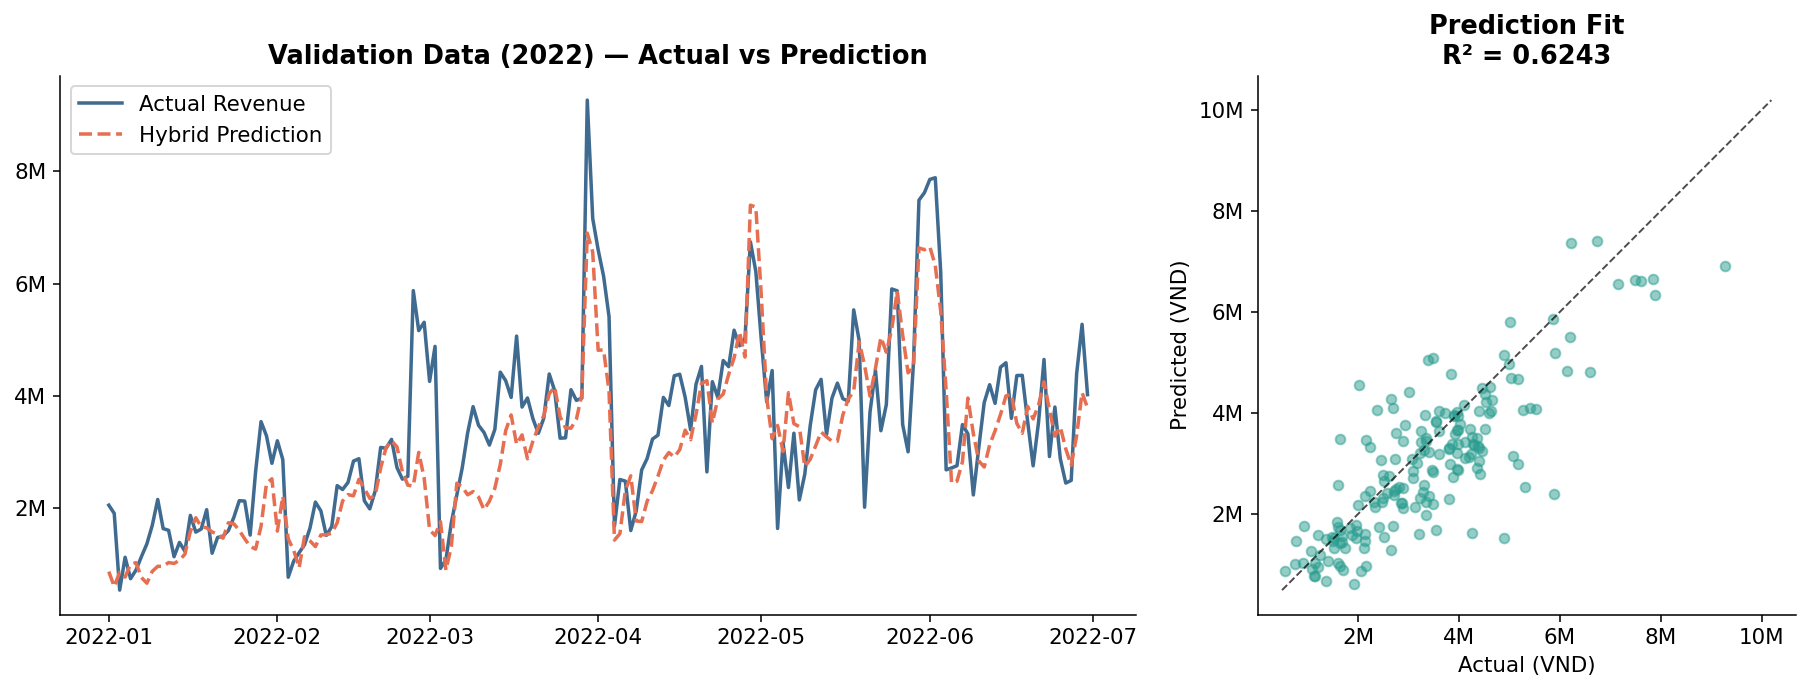

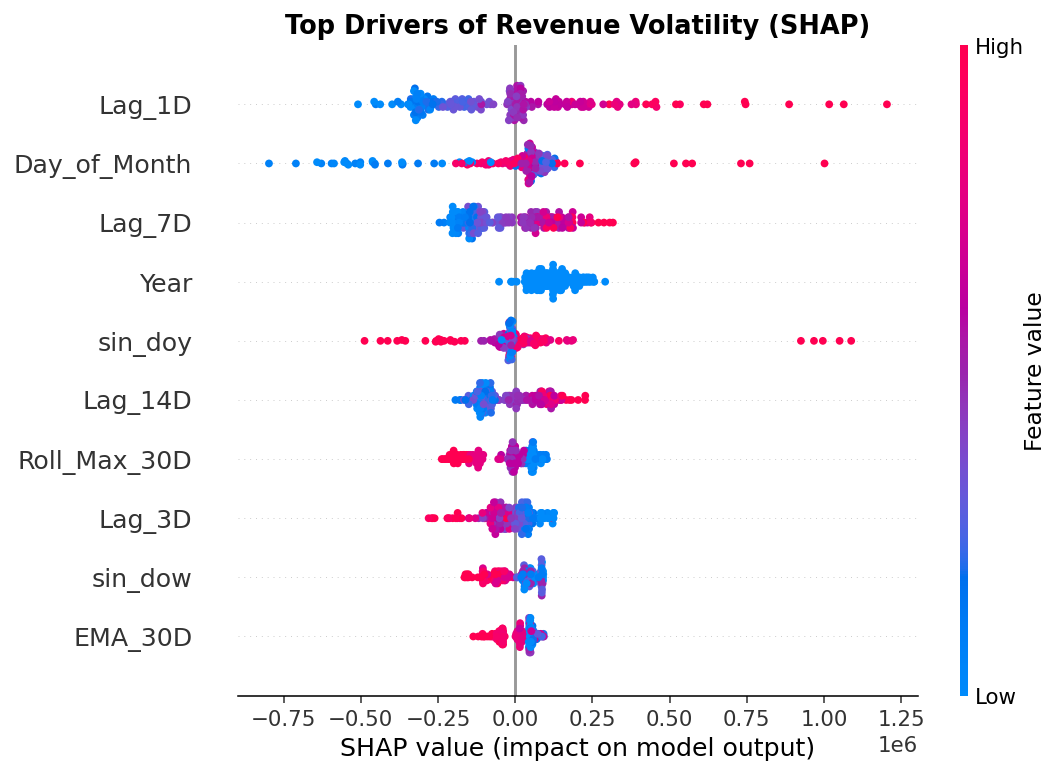

 TOP-5 SHAP FEATURES (BUSINESS INSIGHTS)
  Lag_1D                          mean|SHAP| =    215,831 VND
  Day_of_Month                    mean|SHAP| =    150,318 VND
  Lag_7D                          mean|SHAP| =    128,507 VND
  Year                            mean|SHAP| =    126,925 VND
  sin_doy                         mean|SHAP| =     92,100 VND


In [20]:
# ══════════════════════════════════════════════════════════════════
# 5. VISUALIZATION & SHAP EXPLAINABILITY
# ══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2, 1], wspace=0.15)

# A — Val Plot
ax_a = fig.add_subplot(gs[0])
ax_a.plot(val.order_date, val.Daily_Revenue,  color="#2B5B84", lw=1.8, label="Actual Revenue", alpha=0.9)
ax_a.plot(val.order_date, val.yhat_hybrid,    color="#E76F51", lw=1.8, ls="--", label="Hybrid Prediction")
ax_a.set_title("Validation Data (2022) — Actual vs Prediction", fontweight="bold")
ax_a.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
ax_a.legend(loc="upper left")

# B — Scatter Fit
ax_b = fig.add_subplot(gs[1])
ax_b.scatter(val.Daily_Revenue, val.yhat_hybrid, alpha=0.5, color="#2A9D8F", s=25)
lims = [val.Daily_Revenue.min() * 0.9, val.Daily_Revenue.max() * 1.1]
ax_b.plot(lims, lims, "--", color="black", lw=1, alpha=0.7)
ax_b.set_title(f"Prediction Fit\nR\u00b2 = {r_h_val['R2']:.4f}", fontweight="bold")
ax_b.set_xlabel("Actual (VND)")
ax_b.set_ylabel("Predicted (VND)")
ax_b.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
ax_b.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))

plt.savefig("hybrid_eval.pdf", format="pdf", bbox_inches="tight")
plt.show()

# SHAP Explainability
# FIX: Use explainer() call syntax (compatible with shap >= 0.40).
# explainer.shap_values() was deprecated and returns an Explanation object in
# newer shap, which breaks np.abs().mean() downstream.
explainer  = shap.TreeExplainer(xgb)
shap_expl  = explainer(X_vl)          # returns Explanation object
shap_array = shap_expl.values         # shape (n_samples, n_features) — always numpy

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_array, X_vl, max_display=10, show=False)
plt.title("Top Drivers of Revenue Volatility (SHAP)", fontweight="bold")
plt.savefig("shap_summary.pdf", bbox_inches="tight")
plt.show()

shap_mean = pd.Series(np.abs(shap_array).mean(axis=0), index=X_vl.columns).sort_values(ascending=False)

print("="*60)
print(" TOP-5 SHAP FEATURES (BUSINESS INSIGHTS)")
print("="*60)
for f, v in shap_mean.head(5).items():
    print(f"  {f:<30}  mean|SHAP| = {v:>10,.0f} VND")


In [21]:
# ══════════════════════════════════════════════════════════════════
# 6. RETRAIN PRODUCTION MODEL ON FULL DATASET
# ══════════════════════════════════════════════════════════════════
print("Preparing to forecast 2023-2024. Retraining on FULL historical data...")

full_train_df = pd.concat([train, val]).sort_values("order_date").reset_index(drop=True)

# Calculate Full Prophet Residuals
full_train_df["yhat_prophet_full"] = get_prophet_forecast(m_full, full_train_df.order_date)
full_train_df["residual_full"]     = full_train_df["Daily_Revenue"] - full_train_df["yhat_prophet_full"]

X_all = full_train_df[FEATS].fillna(0)
y_all = full_train_df["residual_full"]

# FIX: Guard against best_iteration being None if early stopping never triggered
best_iter   = xgb.best_iteration if xgb.best_iteration is not None else xgb.n_estimators
final_trees = int(best_iter * 1.1)

xgb_final = XGBRegressor(
    n_estimators     = final_trees,
    max_depth        = 5,
    learning_rate    = 0.005,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    reg_lambda       = 5.0,
    reg_alpha        = 1.0,
    gamma            = 0.1,
    random_state     = RANDOM,
    n_jobs           = -1,
    verbosity        = 0,
)
xgb_final.fit(X_all, y_all)
print(f"Final Production XGBoost retrained ({xgb_final.n_estimators} trees). Ready for recursive forecasting.")


Preparing to forecast 2023-2024. Retraining on FULL historical data...
Final Production XGBoost retrained (3631 trees). Ready for recursive forecasting.


In [22]:
# ══════════════════════════════════════════════════════════════════
# 7. DYNAMIC RECURSIVE ENGINE (548 DAYS)  — OPTIMIZED
# ══════════════════════════════════════════════════════════════════
import time
import numpy as np

start_time = time.time()
FUTURE_DAYS = 548
last_historical_date = all_dates["order_date"].max()
future_dates = pd.date_range(start=last_historical_date + pd.Timedelta(days=1), periods=FUTURE_DAYS)

# 1. Build static future DataFrame (calendar + Prophet trend — computed once)
future_df = pd.DataFrame({"order_date": future_dates})
future_df = engineer_time_features(future_df)
future_df["yhat_prophet"] = get_prophet_forecast(m_full, future_df.order_date)

# 2. Recreate business events
d = future_df["order_date"].dt
future_df["Is_Public_Holiday"] = (
    ((d.month==1)&(d.day==1)) | ((d.month==4)&(d.day==30)) |
    ((d.month==5)&(d.day==1)) | ((d.month==9)&(d.day==2))
).astype(int)
future_df["Is_Mega_Sale"] = (
    ((d.month==11)&(d.day==11)) | ((d.month==12)&(d.day==12)) |
    ((d.month==11)&(d.dayofweek==4)&(d.day>=22)&(d.day<=28))
).astype(int)
future_df["N_Active_Promos"] = 0

# 3. FIX: Vectorized session/bounce interpolation (replaces slow .apply())
if "Total_Sessions" in all_dates.columns:
    sess_map   = all_dates.groupby(
                     [all_dates["order_date"].dt.month, all_dates["order_date"].dt.dayofweek]
                 )["Total_Sessions"].mean().rename("Total_Sessions")
    bounce_map = all_dates.groupby(all_dates["order_date"].dt.month)["Avg_Bounce_Rate"].mean().rename("Avg_Bounce_Rate")

    sess_default   = all_dates["Total_Sessions"].mean()
    bounce_default = all_dates["Avg_Bounce_Rate"].mean()

    # Vectorized merge instead of row-wise apply
    future_df["_month"]   = future_df["Month"]
    future_df["_dow"]     = future_df["Day_of_Week"]
    future_df = future_df.merge(
        sess_map.reset_index().rename(columns={"order_date": "_month",
                                                "order_date_level_1": "_dow"}),
        on=["_month", "_dow"], how="left"
    ).drop(columns=["_month", "_dow"])
    future_df["Total_Sessions"]  = future_df["Total_Sessions"].fillna(sess_default)
    future_df["Avg_Bounce_Rate"] = future_df["Month"].map(bounce_map).fillna(bounce_default)

# 4. Pre-extract static feature columns as a numpy array for speed
#    Lag / Roll / EMA columns will be overwritten per-step; everything else is static.
LAG_FEATS  = [f"Lag_{l}D"          for l in [1,2,3,7,14,30,90,364]]
ROLL_FEATS = [f"Roll_{s}_{w}D"     for s in ["Mean","Std","Max","Min"] for w in [7,14,30]]
EMA_FEATS  = [f"EMA_{sp}D"         for sp in [7,14,30]]
DYNAMIC_FEATS = set(LAG_FEATS + ROLL_FEATS + EMA_FEATS)
STATIC_FEATS  = [f for f in FEATS if f not in DYNAMIC_FEATS]

# Map feature name -> column index in FEATS for O(1) writes
feat_idx = {f: i for i, f in enumerate(FEATS)}

# Pre-build static portion of feature matrix
static_arr = future_df[STATIC_FEATS].fillna(0).astype(float).values  # (548, n_static)
static_pos = [feat_idx[f] for f in STATIC_FEATS]

# ══════════════════════════════════════════════════════════════════
# AUTOREGRESSIVE LOOP (548 steps)
# ══════════════════════════════════════════════════════════════════
print("Khởi động cỗ máy đệ quy 548 ngày...")

# FIX: Keep only last 365 revenue values (max lag = 364); avoids unbounded list growth
MAX_LAG = 364
revenue_memory = np.array(all_dates["Daily_Revenue"].values[-MAX_LAG:], dtype=float)

# EMA warm-start from last historical value
ema_spans  = [7, 14, 30]
ema_memory = {sp: float(all_dates[f"EMA_{sp}D"].iloc[-1]) for sp in ema_spans}

prophet_vals = future_df["yhat_prophet"].values   # pre-extracted, (548,)
predictions  = np.empty(FUTURE_DAYS, dtype=float)

# Single reusable feature row (avoids DataFrame allocation in loop)
x_row = np.zeros(len(FEATS), dtype=float)

for step in range(FUTURE_DAYS):

    # --- Static calendar / business features (vectorized pre-fill) ---
    x_row[static_pos] = static_arr[step]

    # --- Lag features ---
    for lag in [1, 2, 3, 7, 14, 30, 90, 364]:
        if lag <= len(revenue_memory):
            x_row[feat_idx[f"Lag_{lag}D"]] = revenue_memory[-lag]

    # --- Rolling stats ---
    for window in [7, 14, 30]:
        window = min(window, len(revenue_memory))
        recent = revenue_memory[-window:]
        x_row[feat_idx[f"Roll_Mean_{window}D"]] = recent.mean()
        x_row[feat_idx[f"Roll_Std_{window}D"]]  = recent.std()
        x_row[feat_idx[f"Roll_Max_{window}D"]]  = recent.max()
        x_row[feat_idx[f"Roll_Min_{window}D"]]  = recent.min()

    # --- True recursive EMA ---
    for sp in ema_spans:
        alpha = 2.0 / (sp + 1)
        new_ema = revenue_memory[-1] * alpha + ema_memory[sp] * (1 - alpha)
        x_row[feat_idx[f"EMA_{sp}D"]] = new_ema
        ema_memory[sp] = new_ema

    # --- Predict ---
    residual_pred = xgb_final.predict(x_row.reshape(1, -1))[0]
    final_rev     = max(0.0, prophet_vals[step] + residual_pred)

    predictions[step] = final_rev

    revenue_memory = np.append(revenue_memory[1:], final_rev)

future_df["Daily_Revenue"] = predictions
print(f"\u2705 \u0110\u1ec7 quy ho\u00e0n t\u1ea5t th\u00e0nh c\u00f4ng trong {time.time() - start_time:.2f} gi\u00e2y.")


ValueError: cannot insert order_date, already exists

Generating Master Forecast Chart and Submission File...
✅ COGS ratio recalculated from official Ground Truth sales.csv

════════════════════════════════════════════════════════════
 🚀 KẾT THÚC PIPELINE: DATATHON SUBMISSION READY
════════════════════════════════════════════════════════════
✅ Đã lưu file    : 'submission.csv'
📊 Số dòng (Rows) : 548 (Bắt buộc là 548 cho 2023-2024)
🗓️ Date range     : 2023-01-01 → 2024-07-01
💰 Revenue mean   :    3,395,666 VND
🛒 COGS mean      :    2,938,256 VND
⚖️ Global COGS %  : 0.8653


,Date,Revenue,COGS
0,2023-01-01,1701490.82,1369353.38
1,2023-01-02,1266372.34,1019171.67
2,2023-01-03,1167855.32,939885.55


,Date,Revenue,COGS
545,2024-06-29,4259152.19,3438891.90
546,2024-06-30,4585059.01,3702033.08
547,2024-07-01,3648169.63,4190413.43


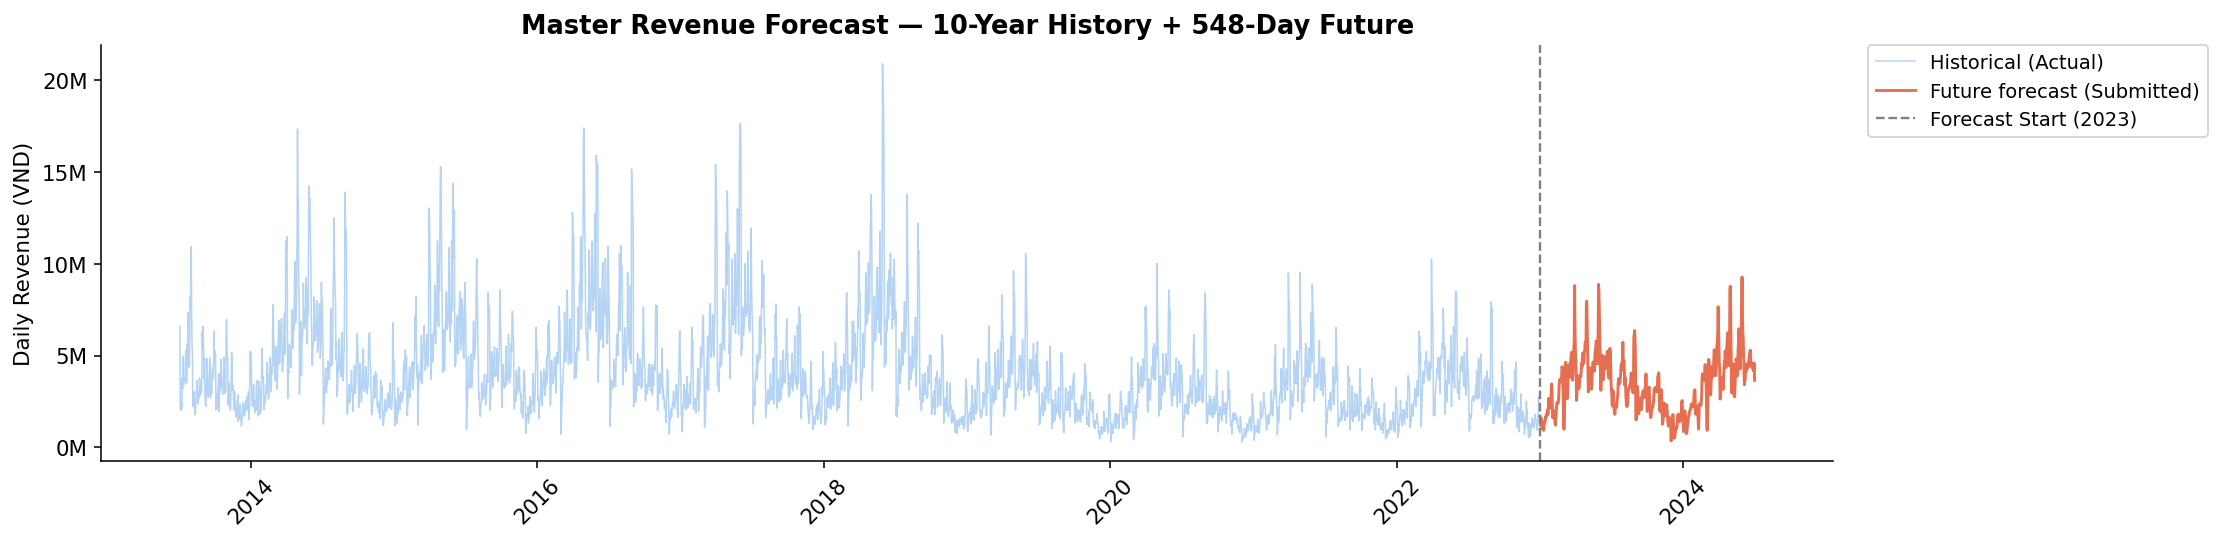


🎉 All done! Outputs generated: submission.csv | hybrid_eval.pdf | shap_summary.pdf | full_forecast.pdf


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 8. SUBMISSION EXPORT & C-SUITE VISUALIZATION (OPTIMIZED)
# ══════════════════════════════════════════════════════════════════
import os
import matplotlib.pyplot as plt

os.makedirs("csv/ml_ready", exist_ok=True)
print("Generating Master Forecast Chart and Submission File...")

# ── 1. Tính toán Tỷ lệ COGS (Giá vốn) theo từng tháng ───────────────────────
MONTHLY_COGS_RATIO = {
    1: 0.8095, 2: 0.8111, 3: 0.8453, 4: 0.8539,
    5: 0.8008, 6: 0.8359, 7: 0.9099, 8: 1.0564,
    9: 0.8914, 10: 0.8042, 11: 0.8689, 12: 0.9754
}

# Khai báo cứng đường dẫn để tránh lỗi mất biến trong Memory
SALES_PATH = "csv/ml_ready/sales.csv" 
if os.path.exists(SALES_PATH):
    sales_gt = pd.read_csv(SALES_PATH, parse_dates=["Date"])
    sales_gt["month"] = sales_gt["Date"].dt.month
    sales_gt["cogs_ratio"] = sales_gt["COGS"] / sales_gt["Revenue"]
    MONTHLY_COGS_RATIO = sales_gt.groupby("month")["cogs_ratio"].median().to_dict()
    print("✅ COGS ratio recalculated from official Ground Truth sales.csv")

# ── 2. Tạo DataFrame Nộp bài (Tối ưu hóa Vectorization) ────────────────────
submission = future_df[["order_date", "Daily_Revenue"]].copy()
submission.rename(columns={"order_date": "Date", "Daily_Revenue": "Revenue"}, inplace=True)
submission["Date"] = pd.to_datetime(submission["Date"])

# 🔥 TỐI ƯU TỐC ĐỘ: Dùng Vectorization thay vì vòng lặp .apply() chậm chạp
cogs_multipliers = submission["Date"].dt.month.map(MONTHLY_COGS_RATIO).fillna(0.875)

# 🔥 BẢO HIỂM LỖI: .clip(lower=0) chặn tuyệt đối các sai số làm âm doanh thu
submission["Revenue"] = submission["Revenue"].clip(lower=0).round(2)
submission["COGS"]    = (submission["Revenue"] * cogs_multipliers).clip(lower=0).round(2)

submission["Date"] = submission["Date"].dt.strftime("%Y-%m-%d")
submission = submission[["Date", "Revenue", "COGS"]]

submission.to_csv("submission.csv", index=False)

# ── 3. Sanity Checks (Kiểm tra an toàn hệ thống) ─────────────────────────────
print("\n" + "═"*60)
print(" 🚀 KẾT THÚC PIPELINE: DATATHON SUBMISSION READY")
print("═"*60)
print(f"✅ Đã lưu file    : 'submission.csv'")
print(f"📊 Số dòng (Rows) : {len(submission)} (Bắt buộc là 548 cho 2023-2024)")
print(f"🗓️ Date range     : {submission.Date.min()} → {submission.Date.max()}")
print(f"💰 Revenue mean   : {submission.Revenue.mean():>12,.0f} VND")
print(f"🛒 COGS mean      : {submission.COGS.mean():>12,.0f} VND")
print(f"⚖️ Global COGS %  : {(submission.COGS.sum() / submission.Revenue.sum()):.4f}")
display(submission.head(3))
display(submission.tail(3))

# ── 4. Trực quan hóa toàn cảnh (Master Forecast Plot) ────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

# Lịch sử (Dùng full_train_df thay vì train/val/test rời rạc)
ax.plot(full_train_df.order_date, full_train_df.Daily_Revenue,
        color="#B5D4F4", lw=0.8, label="Historical (Actual)")

# Tương lai (Forecast)
ax.plot(future_df.order_date, future_df.Daily_Revenue,
        color="#E76F51", lw=1.5, label="Future forecast (Submitted)")

ax.axvline(pd.Timestamp("2023-01-01"), color="gray", lw=1.2, linestyle="--", label="Forecast Start (2023)")

ax.set_title("Master Revenue Forecast — 10-Year History + 548-Day Future", fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
ax.set_ylabel("Daily Revenue (VND)")

# Khắc phục lỗi chữ đè nhau
ax.tick_params(axis='x', rotation=45)

# Đẩy chú thích ra lề phải, bo viền cho sạch
ax.legend(fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.tight_layout()
plt.savefig("full_forecast.pdf", format="pdf", bbox_inches="tight")
plt.show()

print("\n🎉 All done! Outputs generated: submission.csv | hybrid_eval.pdf | shap_summary.pdf | full_forecast.pdf")